# Wind Impact Forecasting for Switzerland
## A Step-by-Step Tutorial using MeteoSwiss Open Government Data and CLIMADA

**Authors:** MeteoSwiss  
**Last updated:** 2025

---

## Introduction

This tutorial demonstrates how to create an **operational impact forecast** for wind storms in Switzerland. We combine:

- **Weather forecasts** from MeteoSwiss Open Government Data (OGD)
- **Impact modeling** using the CLIMADA platform

### What is Impact Forecasting?

Traditional weather forecasting tells us *what the weather will be*. Impact forecasting goes further and tells us *what the weather will do* - estimating potential damage, warnings, and affected populations before an event occurs.

### Pipeline Overview

```
Weather Forecast → Hazard → Exposure → Vulnerability → Impact
     (OGD)       (Wind)   (Buildings)  (Damage curve)  (CHF damage)
```

### Learning Objectives

By the end of this tutorial, you will be able to:

1. Fetch numerical weather prediction data from MeteoSwiss OGD API
2. Convert weather data into CLIMADA hazard objects
3. Create exposure datasets representing assets at risk
4. Apply vulnerability functions to estimate damage
5. Generate impact forecasts and visualizations
6. Aggregate results by administrative regions

---

## Table of Contents

1. [Setup and Imports](#1-Setup-and-Imports)
2. [Fetching Weather Forecast Data from MeteoSwiss OGD](#2-Fetching-Weather-Forecast-Data-from-MeteoSwiss-OGD)
   - [What is ICON-CH2?](#What-is-ICON-CH2?)
   - [Variable: VMAX_10M](#Variable:-VMAX_10M)
   - [API Call](#API-Call)
   - [Understanding the xarray DataArray](#Understanding-the-xarray-DataArray)
3. [Creating a HazardForecast Object](#3-Creating-a-HazardForecast-Object)
   - [Key Components of a Hazard Object](#Key-Components-of-a-Hazard-Object)
   - [Visualizing a Single Event](#Visualizing-a-Single-Event)
4. [Building Exposure: Where Are Assets Located?](#4-Building-Exposure:-Where-Are-Assets-Located?)
   - [What is LitPop?](#What-is-LitPop?)
   - [Exposure Components](#Exposure-Components)
   - [Visualizing Exposure Distribution](#Visualizing-Exposure-Distribution)
   - [Assigning Exposure to Hazard Grid](#Assigning-Exposure-to-Hazard-Grid)
5. [Defining Vulnerability: Impact Functions](#5-Defining-Vulnerability:-Impact-Functions)
   - [The Welker Wind Damage Function](#The-Welker-Wind-Damage-Function)
   - [Creating the Impact Function](#Creating-the-Impact-Function)
   - [Visualizing the Vulnerability Curve](#Visualizing-the-Vulnerability-Curve)
6. [Computing Building Damage Impacts](#6-Computing-Building-Damage-Impacts)
   - [Impact Calculation Formula](#Impact-Calculation-Formula)
   - [Understanding Impact Metrics](#Understanding-Impact-Metrics)
   - [Impact Time Series](#Impact-Time-Series)
   - [Spatial Distribution of Impacts](#Spatial-Distribution-of-Impacts)
7. [Aggregating Results by Canton](#7-Aggregating-Results-by-Canton)
   - [Loading Canton Boundaries](#Loading-Canton-Boundaries)
   - [Spatial Aggregation](#Spatial-Aggregation)
   - [Visualizing Cantonal Impacts](#Visualizing-Cantonal-Impacts)
8. [Summary & Next Steps](#8-Summary-&-Next-Steps)
   - [What We've Learned](#What-We've-Learned)
   - [The Complete Pipeline](#The-Complete-Pipeline)
   - [Extensions and Advanced Topics](#Extensions-and-Advanced-Topics)
   - [Resources](#Resources)
   - [Contact](#Contact)

---

## 1. Setup and Imports

First, let's import all necessary libraries and check our environment.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# CLIMADA
from climada.engine import ImpactCalc
from climada.entity import ImpactFuncSet
from climada.hazard.forecast import HazardForecast

# Impact forecasting modules
from impact_forecasting_warning.hazard.weather_api import fetch_ogd_forecast
from impact_forecasting_warning.hazard.hazard_forecast import create_hazard_forecast
from impact_forecasting_warning.exposure.exposure_data import create_litpop_exposure
from impact_forecasting_warning.vulnerability.wind import from_welker

print("✓ All imports successful!")
print(f"Notebook executed on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All imports successful!
Notebook executed on: 2026-08-13 13:29:37


---

## 2. Fetching Weather Forecast Data from MeteoSwiss OGD

MeteoSwiss provides **Open Government Data** (OGD) including numerical weather prediction (NWP) model outputs. We'll use the **ICON-CH2** model, which provides high-resolution forecasts for Switzerland.

### What is ICON-CH2?

- **Resolution:** ~2 km horizontal grid spacing
- **Domain:** Switzerland and surrounding areas
- **Update frequency:** 4 times per day (00, 06, 12, 18 UTC)
- **Forecast horizon:** Up to 5 days

### Variable: VMAX_10M

We fetch `VMAX_10M` - the **maximum wind gust at 10 meters** above ground, which is the most relevant variable for wind damage assessment.

### API Call

In [72]:
# Fetch 5 days of wind gust forecast
da_forecast = fetch_ogd_forecast(
    model="ogd-forecasting-icon-ch2",
    variable="VMAX_10M",
    reftime="latest",  # Use most recent forecast
    n_days=5)

print("Forecast data retrieved successfully!")
print(f"Data type: {type(da_forecast)}")
print(f"Shape: {da_forecast.shape}")
print(f"Data Variables: {da_forecast.data_vars}")

: 

### Understanding the xarray DataArray

The data is returned as an **xarray.DataArray** with an unstructured grid format:

- **eps:** Ensemble members (deterministic forecast + perturbed ensemble members)
- **lead_time:** Forecast lead times ahead of reference time, grouped into daily **forecast_day** bins
- **cell:** Flattened spatial dimension for unstructured grid points
- **lat / lon:** Coordinates for each grid cell

The data also contains metadata:
- **ref_time:** When the forecast was issued
- **units:** m/s (meters per second)
- **geography:** Unstructured grid covering Switzerland and surrounding areas
- **valid_time:** Computed valid times for each forecast day

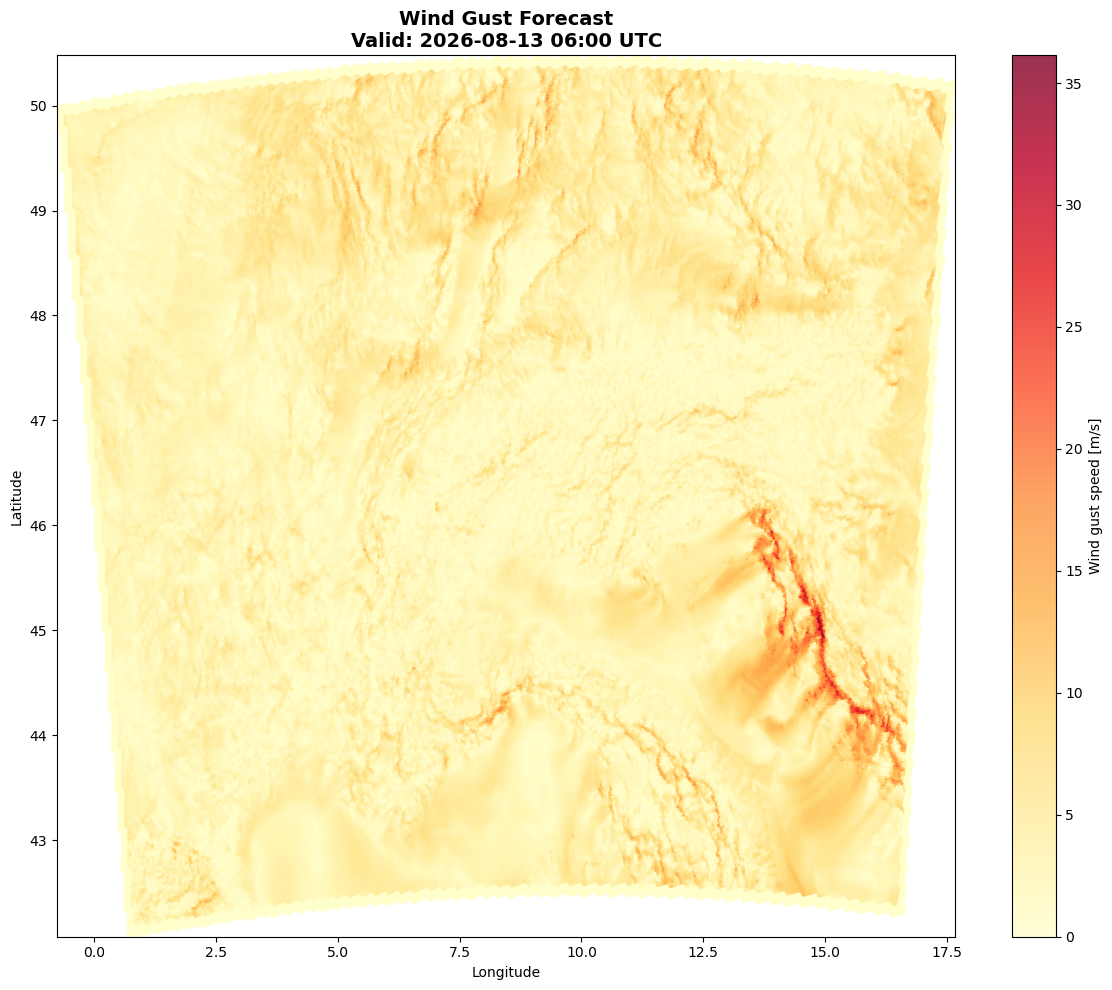

Reference time (forecast issued): 2026-08-13 06:00:00
Number of ensemble members: 21
Number of forecast timesteps: 121
Number of grid cells: 283876


In [11]:
# Select first forecast day and deterministic member
sample_member = da_forecast.eps[0]  # Use deterministic forecast (first member)
sample_hr = da_forecast.lead_time[0]

# Extract data and create scatter plot
data_sample = da_forecast.sel(eps=sample_member, lead_time=sample_hr).values
lats = da_forecast.lat.values
lons = da_forecast.lon.values

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(lons, lats, c=data_sample, s=1, cmap='YlOrRd', alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax, label='Wind gust speed [m/s]')

ref_time = pd.Timestamp(da_forecast.ref_time.values[0])
valid_time = ref_time + pd.Timedelta(sample_hr.values)
ax.set_title(f'Wind Gust Forecast\nValid: {valid_time.strftime("%Y-%m-%d %H:%M UTC")}', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(lons.min(), lons.max())
ax.set_ylim(lats.min(), lats.max())
plt.tight_layout()
plt.show()

print(f"Reference time (forecast issued): {ref_time}")
print(f"Number of ensemble members: {len(da_forecast.eps)}")
print(f"Number of forecast timesteps: {len(da_forecast.lead_time)}")
print(f"Number of grid cells: {len(da_forecast.cell)}")

---

## 3. Creating a HazardForecast Object

CLIMADA uses a standardized **Hazard** data structure. For forecasts, we use **HazardForecast**, which extends the standard hazard with:

- **Lead time information** (hours ahead of reference time)
- **Ensemble member tracking** (for probabilistic forecasts)

### Key Components of a Hazard Object

1. **Centroids:** Geographic points where hazard intensity is defined
2. **Intensity matrix:** Hazard intensity at each centroid for each event
3. **Frequency:** Annual occurrence probability
4. **Event metadata:** Event IDs, names, dates

Let's convert our weather data into daily maxima per ensemble member:

In [14]:
# Convert to CLIMADA HazardForecast
haz_fc, reference_time, lead_times, valid_time_strs, valid_time_prints, _, _ = create_hazard_forecast(
    da_forecast,
    hazard_type="WS",  # Wind Storm
    intensity_unit="m/s",
    variable_name="VMAX_10M")

print("HazardForecast created successfully!")
print(f"\nHazard type: {haz_fc.haz_type}")
print(f"Number of centroids: {haz_fc.centroids.size}")
print(f"Number of events (time steps): {haz_fc.event_id.size}")
print(f"\nReference time: {reference_time}")
print(f"Lead times: {lead_times[:5]}... hours (showing first 5)")
print(f"\nIntensity matrix shape: {haz_fc.intensity.shape}")
print(f"Max wind gust in forecast: {haz_fc.intensity.max():.1f} m/s")

DEBUG: Dataset structure:
<xarray.Dataset> Size: 145MB
Dimensions:       (eps: 21, cell: 283876, forecast_day: 6)
Coordinates:
  * eps           (eps) int64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
    lon           (cell) float32 1MB -0.1544 -0.1637 -0.1915 ... 12.83 12.81
    lat           (cell) float32 1MB 46.97 46.98 46.98 ... 50.08 50.06 50.05
  * forecast_day  (forecast_day) timedelta64[ns] 48B 0 days 1 days ... 5 days
Dimensions without coordinates: cell
Data variables:
    VMAX_10M      (eps, forecast_day, cell) float32 143MB 0.0 0.0 ... 8.397
2026-08-13 14:01:26,615 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2026-08-13 14:01:26,619 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only
HazardForecast created successfully!

Hazard type: WS
Number of centroids: 283876
Number of events (time steps): 126

Reference time: 2026-08-1

### Visualizing a Single Event

Let's plot the hazard intensity for one forecast time:

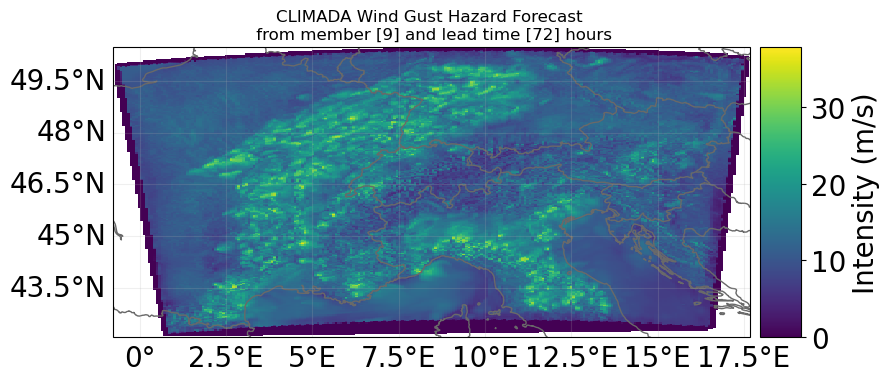

In [21]:
# Select a specific event (lead_time x day) to visualize
event_idx = 72
member_no = haz_fc.select(event_id=[haz_fc.event_id[event_idx]]).member
lead_time = haz_fc.select(event_id=[haz_fc.event_id[event_idx]]).lead_time

# Plot using CLIMADA's built-in visualization
ax = haz_fc.select(event_id=[haz_fc.event_id[event_idx]]).plot_intensity(event=0)
ax.set_title(
    f'CLIMADA Wind Gust Hazard Forecast \n from member {member_no} and lead time {lead_time.astype("timedelta64[h]")} hours'
)
plt.show()

**🎯 Try it yourself:** Modify the code above to plot a different lead time!

---

## 4. Building Exposure: Where Are Assets Located?

**Exposure** represents the assets (people, buildings, infrastructure) that could be affected by a hazard.

### What is LitPop?

**LitPop** is a method that combines:
- **Lit**ness: Night-time light satellite imagery (proxy for economic activity)
- **Pop**ulation: Population density data

This creates a high-resolution map of asset values, even where detailed building data is unavailable.

### Exposure Components

An exposure dataset contains:
- **Coordinates:** Latitude and longitude of each asset
- **Value:** Economic value at each location (in CHF)
- **Metadata:** Asset type, region, etc.

Let's create exposure for Switzerland:

In [22]:
# Create LitPop exposure for Switzerland
exp_ch = create_litpop_exposure(convert_to_chf=True)

print("Exposure created successfully!")
print(f"\nNumber of exposure points: {exp_ch.gdf.shape[0]:,}")
print(f"Total asset value: CHF {exp_ch.gdf.value.sum() / 1e9:.1f} billion")
print(f"\nExposure data preview:")
exp_ch.gdf.head()

Exposure created successfully!

Number of exposure points: 70,287
Total asset value: CHF 1903.3 billion

Exposure data preview:


,value,region_id,impf_,geometry
0,148673.033436,756,1,POINT (8.54583 47.79583)
1,169580.135449,756,1,POINT (8.55417 47.79583)
2,142703.366204,756,1,POINT (8.5625 47.79583)
3,101083.440735,756,1,POINT (8.57083 47.79583)
4,45519.414641,756,1,POINT (8.57917 47.79583)


### Visualizing Exposure Distribution

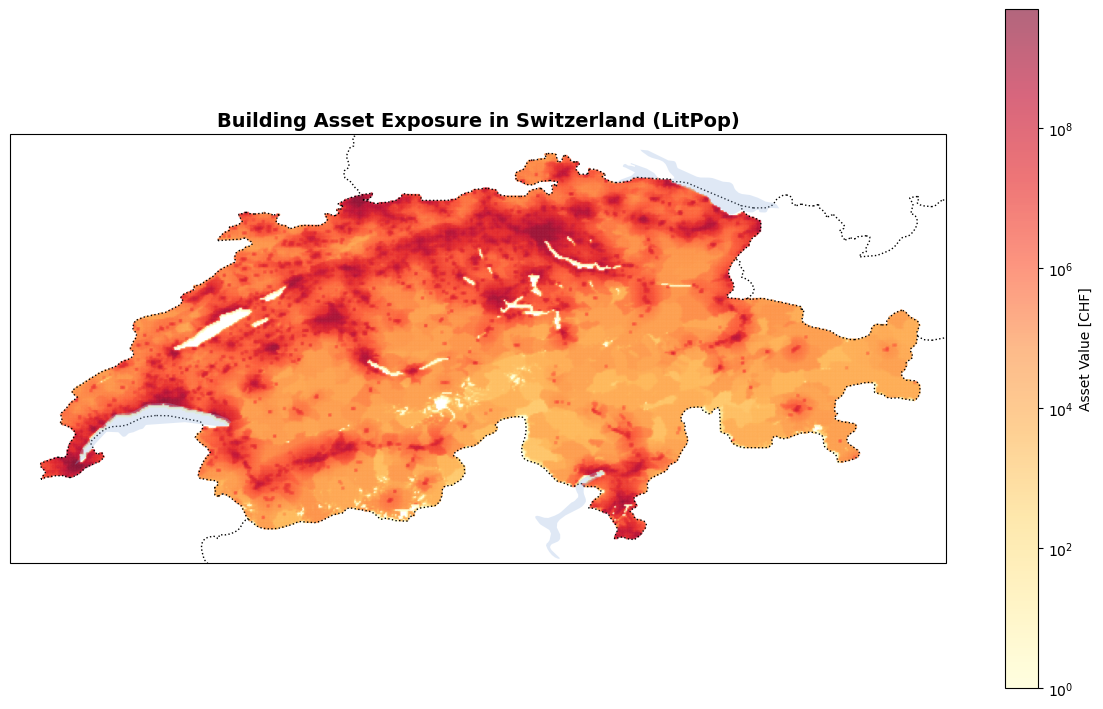


📍 Major urban areas (Zurich, Geneva, Basel) show highest asset concentrations.


In [25]:
# Plot exposure on a map
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Add geographic features
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, alpha=0.3)

# Extract coordinates from geometry
lons = exp_ch.gdf.geometry.x
lats = exp_ch.gdf.geometry.y

# Plot exposure points
scatter = ax.scatter(lons,
                     lats,
                     c=exp_ch.gdf.value,
                     s=1,
                     cmap='YlOrRd',
                     norm=plt.matplotlib.colors.LogNorm(vmin=1e0, vmax=exp_ch.gdf.value.max()),
                     alpha=0.6,
                     transform=ccrs.PlateCarree())

plt.colorbar(scatter, ax=ax, label='Asset Value [CHF]', shrink=0.7)
ax.set_title('Building Asset Exposure in Switzerland (LitPop)', fontsize=14, fontweight='bold')
ax.set_extent([5.8, 10.6, 45.7, 47.9], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

print("\n📍 Major urban areas (Zurich, Geneva, Basel) show highest asset concentrations.")


### Assigning Exposure to Hazard Grid

To calculate impacts, we need to **match exposure points to hazard centroids**. This is done by finding the nearest hazard grid point for each exposure location:

In [26]:
# Assign exposure centroids to hazard grid
# Threshold: maximum distance in km for assignment
exp_ch.assign_centroids(haz_fc, threshold=100)

print("Exposure assigned to hazard grid!")
print(f"Exposure points successfully assigned: {(exp_ch.gdf.centr_WS >= 0).sum():,}")
print(f"Exposure points outside hazard domain: {(exp_ch.gdf.centr_WS < 0).sum():,}")

Exposure assigned to hazard grid!
Exposure points successfully assigned: 70,287
Exposure points outside hazard domain: 0


---

## 5. Defining Vulnerability: Impact Functions

**Vulnerability** describes how susceptible assets are to a given hazard intensity. This is represented by **impact functions** (also called vulnerability curves or damage functions).

### The Welker Wind Damage Function

We use the **Welker et al. (2021)** impact function, developed specifically for Swiss buildings:

- **Input:** Wind gust speed [m/s]
- **Output:** Mean damage ratio (0-1, where 1 = total loss)
- **Based on:** Swiss insurance claim data from historical storms

### Creating the Impact Function

Impact function created!
Function ID: 1
Intensity unit: m/s
Number of intensity points: 131


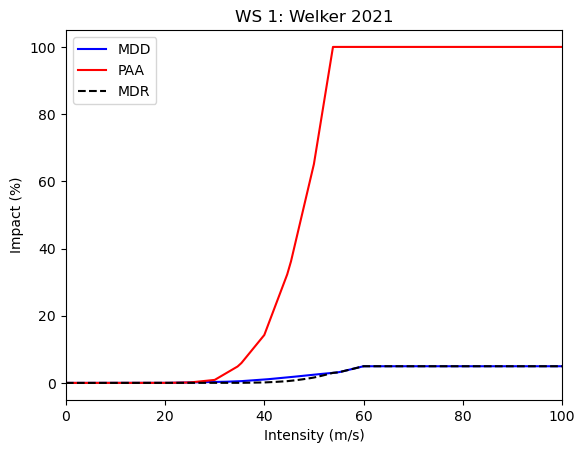

In [28]:
# Create Welker impact function
impf_welker = from_welker()

# Create impact function set (can contain multiple functions)
impf_set = ImpactFuncSet([impf_welker])
impf_welker.plot()
print("Impact function created!")
print(f"Function ID: {impf_welker.id}")
print(f"Intensity unit: {impf_welker.intensity_unit}")
print(f"Number of intensity points: {len(impf_welker.intensity)}")

---

## 6. Computing Building Damage Impacts

Now we have all three components:
1. ✅ **HazardForecast** (wind forecast)
2. ✅ **Exposure** (building values)
3. ✅ **Vulnerability** (damage function)

Let's calculate the **impact forecast**!

### Impact Calculation Formula

For each exposure point:
```
Impact [CHF] = Asset Value [CHF] × Damage Ratio × Wind Speed at that location
```

The `ImpactCalc` engine automates this for all exposure points and all forecast times:

In [35]:
# Calculate impact forecast
imp_fc = ImpactCalc(exp_ch, impf_set, haz_fc).impact(assign_centroids=False)

print("Impact forecast calculated!")
print(f"\nImpact forecast type: {type(imp_fc)}")
print(f"Number of events: {len(imp_fc.event_id)}")
print(f"Number of lead times: {len(np.unique(imp_fc.lead_time))}")
print(f"\nTotal impact range across forecast:")
print(f"  Minimum: CHF {imp_fc.at_event.min() / 1e6:.2f} million")
print(f"  Maximum: CHF {imp_fc.at_event.max() / 1e6:.2f} million")
print(f"  Mean: CHF {imp_fc.at_event.mean() / 1e6:.2f} million")

2026-08-13 14:25:11,555 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
Impact forecast calculated!

Impact forecast type: <class 'climada.engine.impact_forecast.ImpactForecast'>
Number of events: 126
Number of lead times: 6

Total impact range across forecast:
  Minimum: CHF 0.00 million
  Maximum: CHF 11.68 million
  Mean: CHF 0.53 million


### Understanding Impact Metrics

The `ImpactForecast` object contains several key metrics:

- **at_event:** Total impact for each event [CHF]
- **coord_exp:** Impact at each exposure location

### Impact Time Series

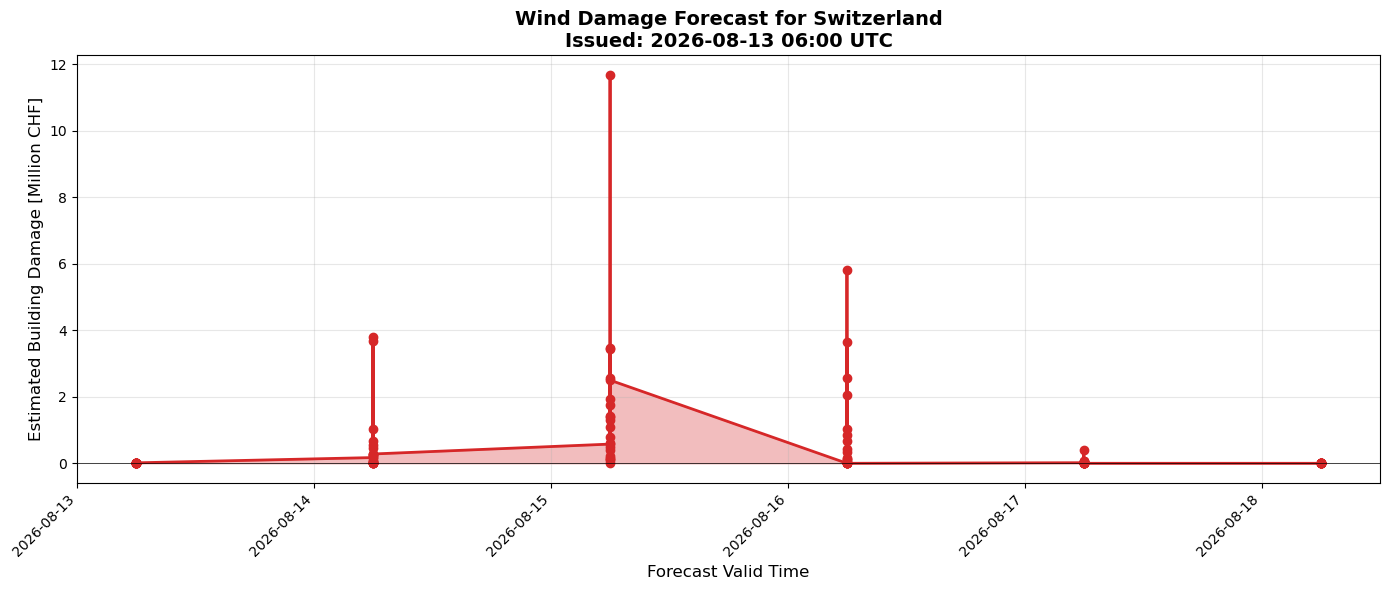


🎯 Peak impact forecast:
  Time: 2026-08-15 06:00 UTC
  Damage: CHF 11.68 million
  Lead time: 48 hours 
  Ensemble member: 7


In [62]:
# Create impact time series plot
fig, ax = plt.subplots(figsize=(14, 6))

# Convert reference_time to datetime
ref_time_dt = pd.Timestamp(reference_time)
valid_times = [ref_time_dt + pd.Timedelta(lt) for lt in imp_fc.lead_time]

ax.plot(valid_times, imp_fc.at_event / 1e6, 'o-', linewidth=2, markersize=6, color='#d62728')
ax.fill_between(valid_times, 0, imp_fc.at_event / 1e6, alpha=0.3, color='#d62728')

ax.set_xlabel('Forecast Valid Time', fontsize=12)
ax.set_ylabel('Estimated Building Damage [Million CHF]', fontsize=12)
ax.set_title(f'Wind Damage Forecast for Switzerland\nIssued: {ref_time_dt.strftime("%Y-%m-%d %H:%M UTC")}',
             fontsize=14,
             fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Format x-axis
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find peak impact
peak_idx = np.argmax(imp_fc.at_event)
peak_time = valid_times[peak_idx]
peak_impact = imp_fc.at_event[peak_idx] / 1e6
peak_member = imp_fc.member[peak_idx]
peak_eventid = imp_fc.event_id[peak_idx]

print(f"\n🎯 Peak impact forecast:")
print(f"  Time: {peak_time.strftime('%Y-%m-%d %H:%M UTC')}")
print(f"  Damage: CHF {peak_impact:.2f} million")
print(f"  Lead time: {imp_fc.lead_time[peak_idx].astype('timedelta64[h]')} ")
print(f"  Ensemble member: {peak_member}")

### Spatial Distribution of Impacts

Let's visualize where damage is expected for the peak impact time:

Text(0.5, 1.0, 'Max. expected building damages from \n member 7 at 2026-08-15 06:00:00 (lead time 48 hours hours)\n CHF 11.68 million')

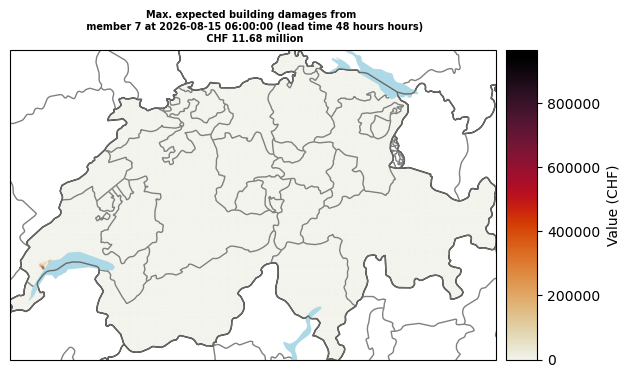

In [63]:
admin1 = cfeature.NaturalEarthFeature(category="cultural", name="admin_1_states_provinces_lines", scale="10m")
lakes = cfeature.LAKES.with_scale("10m")
borders = cfeature.BORDERS.with_scale("10m")

fig = plt.figure()
ax = plt.axes(projection=ccrs.Mercator())
ax.add_feature(borders, linewidth=1)
ax.add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
ax.add_feature(lakes, facecolor="lightblue")
imp_fc.plot_hexbin_impact_exposure(event_id=peak_eventid, pop_name=False, axis=ax)
ax.set_title(
    f"Max. expected building damages from \n member "
    f"{peak_member} at {peak_time} (lead time {imp_fc.lead_time[peak_idx].astype('timedelta64[h]')} hours)"
    f"\n CHF {peak_impact:.2f} million",
    fontsize=7,
    fontweight='bold')


### Aggregating Results by Canton

For operational decision-making, it's helpful to aggregate impacts by administrative regions. Let's summarize damages by Swiss canton.

**Loading Canton Boundaries**

In [66]:
from impact_forecasting_warning.exposure.exposure_data import load_geodataframes

# Load Swiss geodata
gdf_warningregions, gdf_cantons, shift_center_of_mass_by_name = load_geodataframes()

print(f"Loaded {len(gdf_cantons)} cantons")
print(f"\nCantons: {', '.join(gdf_cantons.name.values)}")

Loaded 26 cantons

Cantons: Aargau, Appenzell Ausserrhoden, Appenzell Innerrhoden, Basel-Landschaft, Basel-Stadt, Bern, Fribourg, Genève, Glarus, Graubünden, Jura, Luzern, Neuchâtel, Nidwalden, Obwalden, Schaffhausen, Schwyz, Solothurn, St. Gallen, Tessin, Thurgau, Uri, Valais, Vaud, Zug, Zürich


**Spatial Aggregation**

In [ ]:
# Select peak impact for aggregation
impact_for_agg = peak_impact_obj.mean()  # Use mean across ensemble if probabilistic

# Create GeoDataFrame of exposure points with impacts
impact_per_exp_full = impact_for_agg.imp_mat.toarray().flatten()
exp_gdf = exp_ch.gdf.copy()
exp_gdf['impact'] = impact_per_exp_full
exp_gdf = gpd.GeoDataFrame(exp_gdf, geometry='geometry', crs='EPSG:4326')

# Spatial join: assign each exposure point to a canton
exp_gdf = exp_gdf.to_crs(gdf_cantons.crs)
exp_with_canton = gpd.sjoin(exp_gdf, gdf_cantons[['name', 'geometry']], how='left', predicate='within')

# Aggregate impacts by canton
canton_impacts = exp_with_canton.groupby('name')['impact'].sum().sort_values(ascending=False)

print("\n📊 Top 10 Cantons by Forecasted Damage:\n")
for i, (canton, impact) in enumerate(canton_impacts.head(10).items(), 1):
    print(f"{i:2d}. {canton:20s} CHF {impact/1e6:8.2f} million")

print(f"\nTotal: CHF {canton_impacts.sum()/1e6:.2f} million")


📊 Top 10 Cantons by Forecasted Damage:

 1. Vaud                 CHF     0.71 million
 2. Neuchâtel            CHF     0.14 million
 3. Solothurn            CHF     0.14 million
 4. Zürich               CHF     0.11 million
 5. Aargau               CHF     0.10 million
 6. St. Gallen           CHF     0.10 million
 7. Bern                 CHF     0.10 million
 8. Genève               CHF     0.08 million
 9. Basel-Landschaft     CHF     0.08 million
10. Fribourg             CHF     0.05 million

Total: CHF 1.70 million


**Visualizing Cantonal Impacts**

In [ ]:
# Create choropleth map
gdf_cantons_impact = gdf_cantons.copy()
gdf_cantons_impact['impact'] = gdf_cantons_impact['name'].map(canton_impacts).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Map
gdf_cantons_impact.plot(column='impact',
                        cmap='YlOrRd',
                        linewidth=0.5,
                        edgecolor='black',
                        legend=True,
                        legend_kwds={
                            'label': 'Damage [CHF]',
                            'shrink': 0.7
                        },
                        ax=ax1)
ax1.set_title(f'Wind Damage by Canton\n{peak_time.strftime("%Y-%m-%d %H:%M UTC")}', fontsize=12, fontweight='bold')
ax1.axis('off')

# Bar chart
top_cantons = canton_impacts.head(10)
ax2.barh(range(len(top_cantons)), top_cantons.values / 1e6, color='#d62728')
ax2.set_yticks(range(len(top_cantons)))
ax2.set_yticklabels(top_cantons.index)
ax2.set_xlabel('Estimated Damage [Million CHF]', fontsize=11)
ax2.set_title('Top 10 Affected Cantons', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

**🎯 Try it yourself:** Calculate and visualize impacts for a different forecast time!

---

## 8. Generating Hazard-Based Warnings

Other than impact-based estimates, we can simply generate **hazard-based warnings** using elevation-dependent thresholds. This creates categorical warning levels based on wind intensity alone, independent of assets.

### Why Elevation-Dependent Thresholds?

Swiss buildings at different elevations have different wind vulnerabilities:
- **Low elevation (< 1600m):** Lower wind speed thresholds for damage
- **High elevation (≥ 1600m):** Higher thresholds due to stronger construction standards and naturally adapted building practices

### Creating Warning Impact Functions

In [ ]:

# Create elevation-based warning impact functions
impf_set_warning = create_warning_impact_functions()

# Display warning thresholds
print("Warning Impact Functions:")
for impf in impf_set_warning.funcs:
    print(f"\n{impf.name}:")
    print(f"  Elevation class: {impf.id}")
    print(f"  Thresholds (m/s):")
    for i in range(1, len(impf.intensity), 2):
        print(f"    Level {(i+1)//2}: {impf.intensity[i]:.1f} m/s")

### Calculating Warning Impacts
To generate warnings, we need elevation-aware exposure (constant value per location, independent of building assets):

In [ ]:
# Prepare elevation-based exposure
constant_exp = prepare_elevation_based_exposure(haz_fc, elevation_threshold=1600.0)

print(f"Elevation-based exposure created: {len(constant_exp.gdf)} points")
print(f"Low elevation points: {(constant_exp.gdf['impf_'] == 1).sum():,}")
print(f"High elevation points: {(constant_exp.gdf['impf_'] == 2).sum():,}")

### Computing Warnings
Now calculate warning levels for each forecast time:

In [ ]:
# Calculate warning impacts
imp_warnings = ImpactCalc(constant_exp, impf_set_warning, haz_fc).impact(assign_centroids=False)

print(f"Warning impacts calculated: {len(imp_warnings.event_id)} events")
print(f"Warning levels range: {imp_warnings.at_event.min():.0f} to {imp_warnings.at_event.max():.0f}")

### Visualizing Warnings by Region


In [ ]:
# Load administrative regions
gdf_warningregions, _, _ = load_geodataframes()

# Aggregate warnings by region
warning_by_region = u_func.aggregate_impacts_by_gdf(imp_warnings, gdf_warningregions, "median")

# Create warning map
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

u_func.plot_impact_polygons(
    imp_warnings,
    gdf_warningregions,
    agg_func="median",
    title=f"Hazard-Based Wind Warnings for Switzerland\nIssued: {reference_time}",
    figsize=(12, 10)
)
plt.show()

print("\n⚠️ Warning levels by region:")
for region, warning_level in warning_by_region.nlargest(10, 0).items():
    print(f"  {region}: Level {int(warning_level)}")

**Interpreting Warning Levels**

Level 1: Minimal or no damage expected
Level 2: Light damage possible
Level 3: Moderate damage expected
Level 4: Heavy damage expected
Level 5: Severe damage likely

**Key Difference from Impact Forecasts:**

Damage forecasts (Section 6): Account for asset value → CHF losses
Hazard warnings (this section): Pure wind intensity → categorical levels

---

## 9. Summary & Next Steps

### What We've Learned

In this tutorial, you've successfully:

1. ✅ **Fetched NWP data** from MeteoSwiss Open Government Data API
2. ✅ **Created hazard objects** using CLIMADA's forecast framework
3. ✅ **Built exposure datasets** representing building values
4. ✅ **Applied vulnerability functions** to estimate damage
5. ✅ **Calculated impact forecasts** for multiple time horizons
6. ✅ **Aggregated results** by administrative regions
7. ✅ **Created visualizations** for operational decision-making

### The Complete Pipeline

see also the executable scripts in `pipelines/`

### Extensions and Advanced Topics

You can extend this pipeline in many ways:

1. **Other hazards:** Precipitation, flooding, hail, lightning
2. **Ensemble forecasts:** Process probabilistic forecasts (multiple ensemble members)
3. **Multi-model combinations:** Combine ICON-CH1, ICON-CH2, ECMWF-IFS for seameless forecasts
4. **Automated operations:** Schedule pipeline to run on new forecast releases
5. **Different exposure:** Critical infrastructure, agriculture, population
6. **Uncertainty quantification:** Confidence intervals, skill scores
7. **Impact-based warnings:** Threshold-based alert generation

### Resources

- **CLIMADA Documentation:** https://climada-python.readthedocs.io/
- **MeteoSwiss OGD:** https://www.meteoswiss.admin.ch/services-and-publications/service/open-government-data.html
- **Impact Forecasting Tutorial:** https://github.com/CLIMADA-project/climada_python

### Contact

For questions about this tutorial or the impact forecasting pipeline:
- MeteoSwiss: [contact information]
- CLIMADA: https://github.com/CLIMADA-project/climada_python/issues

---

**Thank you for completing this tutorial!** 🎉